<!-- WARNING: THIS FILE WAS AUTOGENERATED! DO NOT EDIT! -->

## Setup imports

In [ ]:
import os
import tempfile

from bioMONAI.data import *
from bioMONAI.core import *
from bioMONAI.metrics import accuracy
from bioMONAI.losses import CrossEntropyLossFlat

from monai.networks.nets import DenseNet121
from monai.apps import MedNISTDataset

## Setup data directory

You can specify a directory.  
This allows you to save results and reuse downloads.  
If not specified a temporary directory will be used.

In [ ]:
base_directory = '../_data/'
if base_directory is not None:
    os.makedirs(base_directory, exist_ok=True)
root_dir = tempfile.mkdtemp() if base_directory is None else base_directory
print(root_dir)

../../_data/


## Use MONAI transforms to preprocess data

Medical images require specialized methods for I/O, preprocessing, and augmentation.
They often follow specific formats, are handled with specific protocols, and the data arrays are often high-dimensional.

In this example, we will perform image loading, data format verification, and intensity scaling with three `monai.transforms` listed below, and compose a pipeline ready to be used in next steps.

## Prepare datasets using MONAI Apps

We use `MedNISTDataset` in MONAI Apps to download a dataset to the specified directory and perform the pre-processing steps in the `monai.transforms` compose.

The MedNIST dataset was gathered from several sets from [TCIA](https://wiki.cancerimagingarchive.net/display/Public/Data+Usage+Policies+and+Restrictions),
[the RSNA Bone Age Challenge](http://rsnachallenges.cloudapp.net/competitions/4),
and [the NIH Chest X-ray dataset](https://cloud.google.com/healthcare/docs/resources/public-datasets/nih-chest).

The dataset is kindly made available by [Dr. Bradley J. Erickson M.D., Ph.D.](https://www.mayo.edu/research/labs/radiology-informatics/overview) (Department of Radiology, Mayo Clinic)
under the Creative Commons [CC BY-SA 4.0 license](https://creativecommons.org/licenses/by-sa/4.0/).

If you use the MedNIST dataset, please acknowledge the source. 

In [ ]:
from monai.transforms import LoadImageD, EnsureChannelFirstD, ScaleIntensityD, Compose

transform = Compose(
    [
        LoadImageD(keys="image", image_only=True),
        EnsureChannelFirstD(keys="image"),
        ScaleIntensityD(keys="image"),
    ]
)

In [ ]:
train_ds = MedNISTDataset(root_dir=root_dir, transform=transform, section="training", download=False)
val_ds = MedNISTDataset(root_dir=root_dir, transform=transform, section="validation", download=False)
test_ds = MedNISTDataset(root_dir=root_dir, transform=transform, section="test", download=False)

Loading dataset: 100%|██████████| 5895/5895 [00:02<00:00, 2164.60it/s]


In [ ]:
data_ops = {
    'x_keys': 'image',
    'y_keys': 'label', 
    'bs': 512,
    'shuffle': True,
    'vocab': ['AbdomenCT','BreastMRI','ChestCT','CXR','Hand','HeadCT'],
    'show_summary': True,
}

data = BioDataLoaders.from_monai(train_ds, val_ds, **data_ops)


Train DataLoader
----------------
Dataset size : 47164
Batch size   : 512
Batches      : 93
Classes      : ['AbdomenCT', 'BreastMRI', 'ChestCT', 'CXR', 'Hand', 'HeadCT']

Batch structure:
  [0] shape=(512, 1, 64, 64) dtype=torch.float32 ~8.00 MB
  [1] shape=(512,) dtype=torch.int64 ~0.00 MB
Approx batch memory: 8.00 MB

Valid DataLoader
----------------
Dataset size : 5895
Batch size   : 1024
Batches      : 6
Classes      : ['AbdomenCT', 'BreastMRI', 'ChestCT', 'CXR', 'Hand', 'HeadCT']

Batch structure:
  [0] shape=(1024, 1, 64, 64) dtype=torch.float32 ~16.00 MB
  [1] shape=(1024,) dtype=torch.int64 ~0.01 MB
Approx batch memory: 16.01 MB


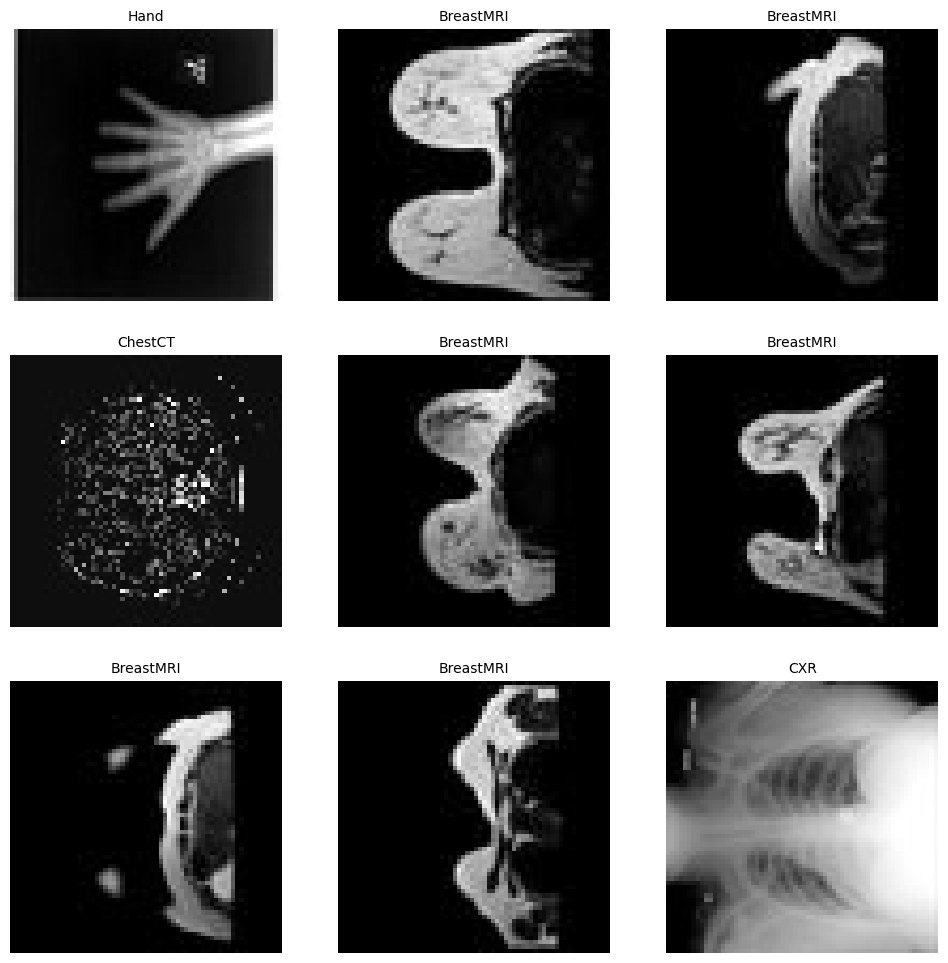

In [ ]:
data.show_batch()

## Define a network and a supervised trainer

To train a model that can perform the classification task, we will use the DenseNet-121 which is known for its performance on the ImageNet dataset.

For a typical supervised training workflow, MONAI provides `SupervisedTrainer` to define the hyper-parameters.

In [ ]:
max_epochs = 5
model = DenseNet121(spatial_dims=2, in_channels=1, out_channels=6)
loss_function = CrossEntropyLossFlat()
metrics = [accuracy]

trainer = fastTrainer(data, model, loss_fn=loss_function, metrics=metrics, show_summary=False, lr=1e-5)

## Run the training

epoch,train_loss,valid_loss,accuracy,time
0,0.742293,0.385844,0.965394,00:14
1,0.272581,0.133415,0.983715,00:11
2,0.116980,0.067816,0.989652,00:11
3,0.060946,0.040167,0.993724,00:11
4,0.034605,0.026329,0.995250,00:12


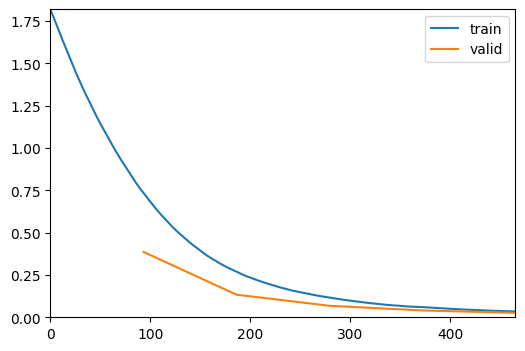

In [ ]:
trainer.fit(max_epochs)

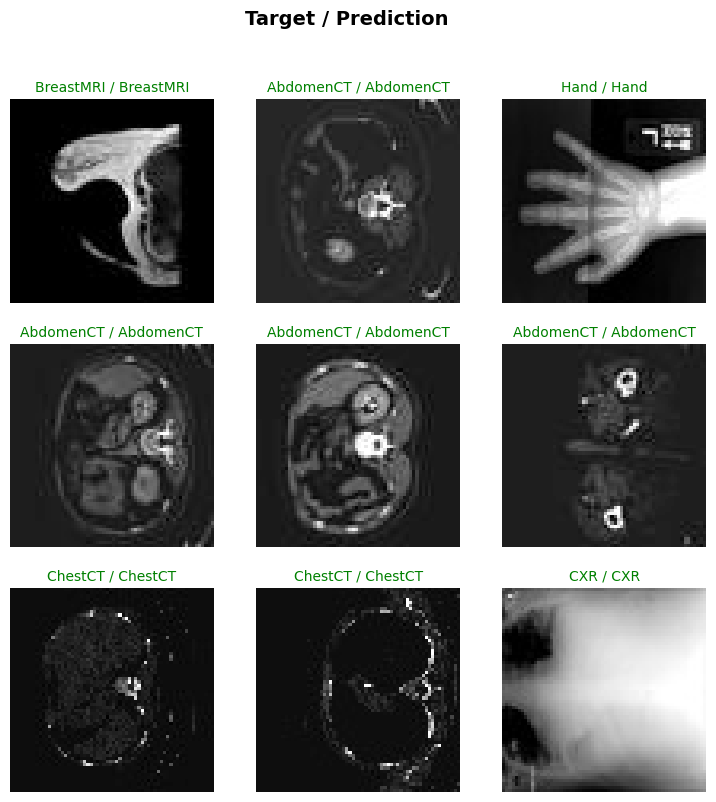

In [ ]:
trainer.show_results()

## Check the prediction on the test dataset

In [ ]:
test_dl = test_biodataloader(data, test_ds) # type:ignore

              precision    recall  f1-score   support

   AbdomenCT       0.99      1.00      1.00       993
   BreastMRI       1.00      0.99      1.00       903
         CXR       1.00      1.00      1.00       968
     ChestCT       1.00      1.00      1.00       998
        Hand       1.00      1.00      1.00       996
      HeadCT       1.00      1.00      1.00      1037

    accuracy                           1.00      5895
   macro avg       1.00      1.00      1.00      5895
weighted avg       1.00      1.00      1.00      5895




Most Confused Classes:


,Actual Class,Predicted Class,Count
0,BreastMRI,AbdomenCT,5
1,HeadCT,AbdomenCT,3
2,CXR,Hand,2
3,Hand,BreastMRI,2
4,AbdomenCT,HeadCT,1
5,BreastMRI,ChestCT,1
6,Hand,CXR,1
7,Hand,HeadCT,1


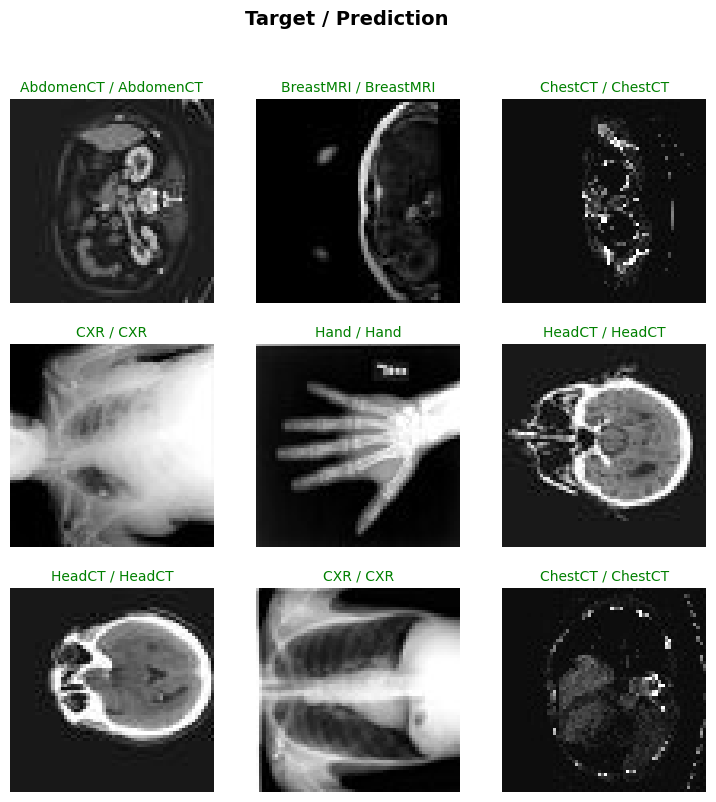

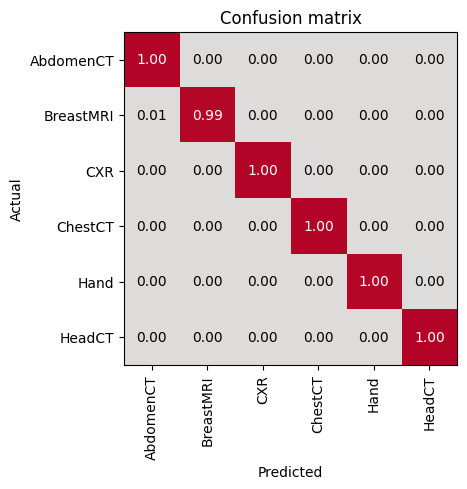

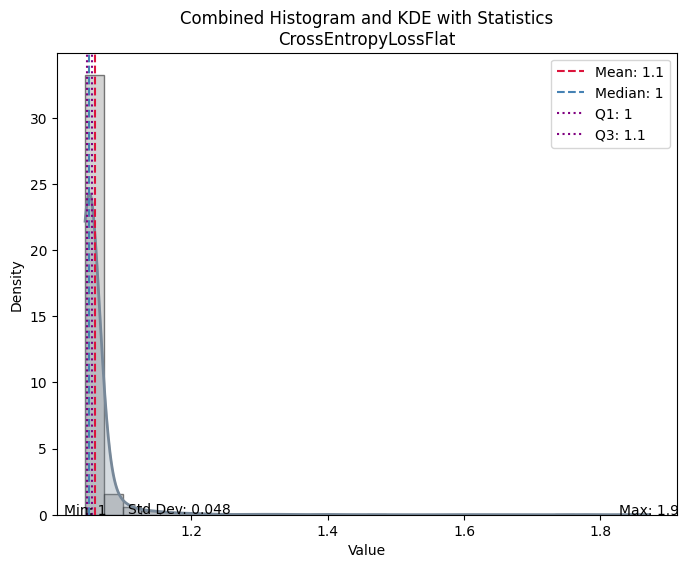

,Value
CrossEntropyLossFlat,
Mean,1.059131
Median,1.049874
Standard Deviation,0.047636
Min,1.044432
Max,1.870728
Q1,1.047687
Q3,1.054943


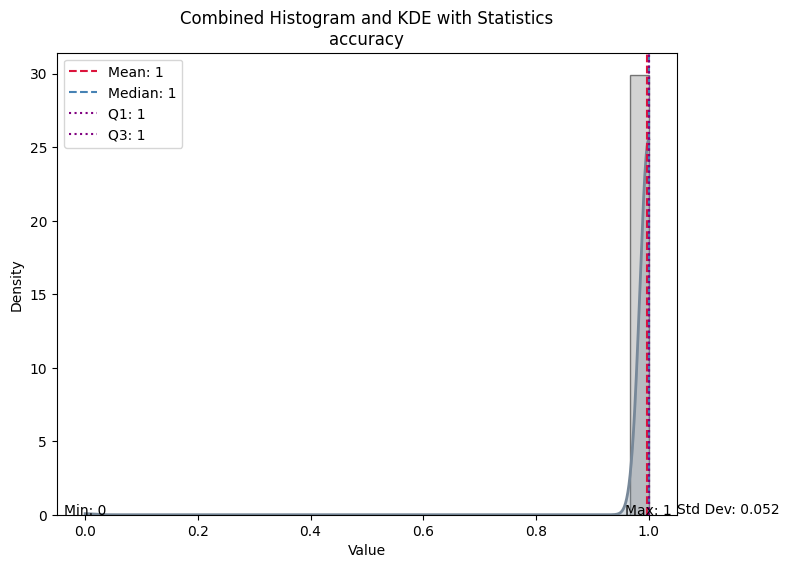

,Value
accuracy,
Mean,0.997286
Median,1.000000
Standard Deviation,0.052027
Min,0.000000
Max,1.000000
Q1,1.000000
Q3,1.000000


In [ ]:
evaluate_classification_model(trainer, test_data=test_dl, metrics=accuracy, show_graph=True, show_results=True); # type:ignore